In [18]:
import json
import os
import csv
import cv2
import numpy as np
import pandas as pd
import random
import datetime
import requests
import matplotlib.pyplot as plt

# Create task

In [19]:
data = []
for type in ["train","test"]:
    csv_file = f"../../emoticon-data/FEC_dataset/faceexp-comparison-data-{type}-public.csv"
    df = pd.read_csv(csv_file, names=[str(i) for i in range(30)], header=None)
    data.extend(df.values.tolist())
len(data)

500203

In [20]:
data[2]

['http://farm5.staticflickr.com/4108/5185055338_1dec873bf3_b.jpg',
 0.142578,
 0.266602,
 0.065421,
 0.297508,
 'http://farm4.staticflickr.com/3858/14540292875_ffb91ba2fb_b.jpg',
 0.206442,
 0.524158,
 0.078125,
 0.325195,
 'http://farm5.staticflickr.com/4116/4747184973_2ffe91f793_b.jpg',
 0.387695,
 0.547852,
 0.184694,
 0.380612,
 'ONE_CLASS_TRIPLET',
 300901,
 2,
 321902,
 2,
 322102,
 1,
 4295017797,
 1,
 4295017896,
 1,
 48316,
 2,
 nan,
 nan]

In [43]:
def get_image(row, col=0, crop=True):
    cached="fec_cache/" + row[col].replace('http://','').replace('https://','')
    if cached[-1] == '/': cached += "index"
    is_local = os.path.isfile(cached)
    if is_local:
        f = open(cached, 'rb')
        b = f.read()
        f.close()
    else:
        try:
            response = requests.get(row[col], timeout=4)
            if response.status_code == 200:
                b = response.content
            else:
                b = b''
        except:
            print(f"Failed to reach {row[col]}")
            b = b''

        if not os.path.isdir(os.path.dirname(cached)):
            os.makedirs(os.path.dirname(cached))
        if len(cached)<250:
            f = open(cached, 'wb')
            f.write(b)
            f.close()
    if len(b) == 0:
        if not is_local:
            print(f"Failed to read {cached}")
        return None
    img = cv2.imdecode(np.asarray(bytearray(b)), cv2.IMREAD_COLOR)
    if img is None or img.shape[0]==0 or img.shape[1]==0:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    if not crop:
        return img
    X_min=int(img.shape[1]*row[col+1])
    X_max=int(img.shape[1]*row[col+2])
    Y_min=int(img.shape[0]*row[col+3])
    Y_max=int(img.shape[0]*row[col+4])
    img_cropped = img[Y_min:Y_max,X_min:X_max]
    return img_cropped

In [44]:
original_base="../../emoticon-data/FEC_dataset/triplets"
originals = os.listdir(original_base)
original_imgs = [cv2.cvtColor(cv2.imread(original_base+"/"+f, cv2.IMREAD_COLOR), 
                              cv2.COLOR_BGR2RGB) for f in originals]

In [45]:
mindist= np.ones((9))*1e100
bestmatch=[[]] * 9
CACHE={}

In [48]:
for i in range(0, len(data)):
    if i % 1000 == 0:
        print(f"\nProcessing row {i}")
    elif i % 20 == 0:
        print(".", end="")
    for j in [0,5,10]:
        row = data[i][j:j+5]
        mkey = f"{row!a}"
        if mkey in CACHE:
            break
        img = get_image(row)
        if img is None:
            continue
        for o in range(9):
            s = original_imgs[o].shape
            if img.shape[0]==0 or img.shape[1]==0: continue
            img2 = cv2.resize(img, (s[1],s[0]))
            dist = np.linalg.norm(1.0 * original_imgs[o] - 1.0 * img2)
            if dist < mindist[o]:
                mindist[o]=dist
                bestmatch[o]=row
                if dist<5000:
                    print(f"Found: {row[0]}")
        CACHE[mkey]=True
        break


Processing row 0
.................................................
Processing row 1000
.................................................
Processing row 2000
.................................................
Processing row 3000
.................................................
Processing row 4000
.................................................
Processing row 5000
.................................................
Processing row 6000
.................................................
Processing row 7000
.................................................
Processing row 8000
.................................................
Processing row 9000
.................................................
Processing row 10000
.................................................
Processing row 11000
.................................................
Processing row 12000
.................................................
Processing row 13000
.................................................
Processing row 140

Corrupt JPEG data: 10 extraneous bytes before marker 0xd9


............................................
Processing row 125000
.................................................
Processing row 126000
.................................................
Processing row 127000
.................................................
Processing row 128000
.................................................
Processing row 129000
.................................................
Processing row 130000
.................................................
Processing row 131000
.................................................
Processing row 132000
.................................................
Processing row 133000
.................................................
Processing row 134000
.................................................
Processing row 135000
.................................................
Processing row 136000
.................................................
Processing row 137000
.................................................
Processing row 1380

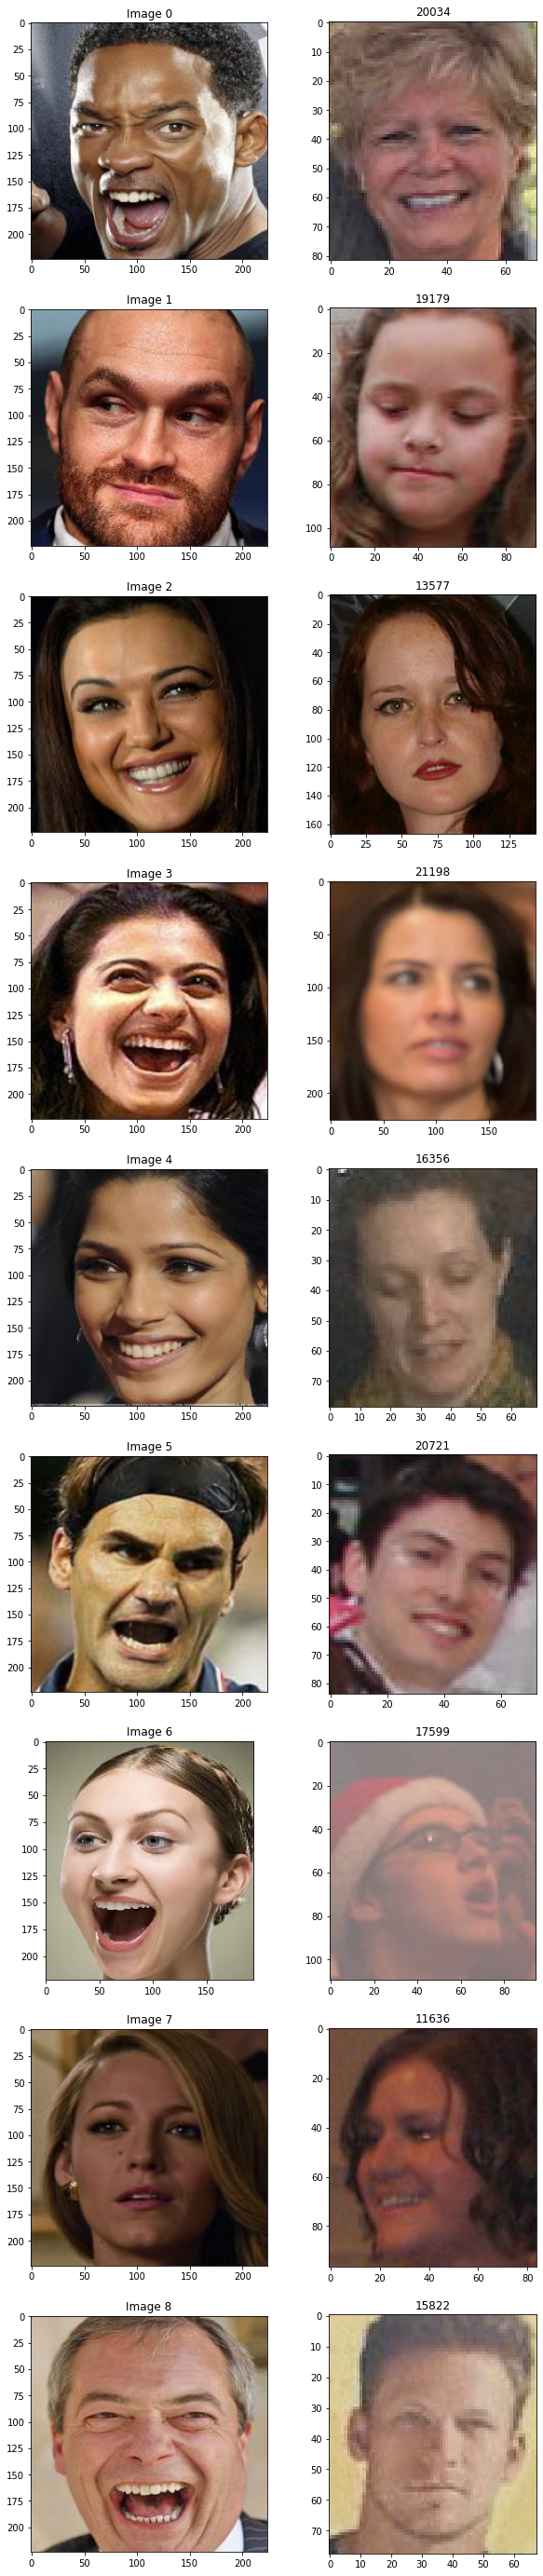

In [50]:
fig,ax = plt.subplots(9,2,figsize=(10,50))
for o in range(9):
    ax[o][0].imshow(original_imgs[o])
    ax[o][0].set_title(f"Image {o}")
    ax[o][1].imshow(get_image(bestmatch[o]))
    ax[o][1].set_title(f"{mindist[o]:.0f}")

# Create task

In [7]:
I = np.random.choice(range(len(data)), 200)
selection=[data[i] for i in I]

In [8]:
def is_online(row):
    return get_image(row,0) is not None and \
        get_image(row,5) is not None and \
        get_image(row,10) is not None


In [9]:
selection = [row for row in selection if is_online(row)]
len(selection)

Failed to read fec_cache/www.telegraphindia.com/1110211/images/11sree1.jpg
Failed to read fec_cache/cdn1.belfasttelegraph.co.uk/news/local-national/northern-ireland/article30294574.ece/99ea3/ALTERNATES/h342/NWS_2014-05-22_NEW_002_31756007_I1.JPG
Failed to reach http://rnbmain.thisisrnb.netdna-cdn.com/wp-content/uploads/2009/09/grammy51_shawn_stockman.jpg
Failed to read fec_cache/rnbmain.thisisrnb.netdna-cdn.com/wp-content/uploads/2009/09/grammy51_shawn_stockman.jpg
Failed to reach http://bezformata.ru/content/Images/000/051/178/image51178313.jpg
Failed to read fec_cache/bezformata.ru/content/Images/000/051/178/image51178313.jpg


163

In [15]:
work=[]
keys=[]
for row in selection:
    for col in [0,5,10]:
        key = f"{row[col:col+5]!a}"
        if not key in keys:
            img = get_image(row,col,False)
            keys.append(key)
            work.append({
                "url": row[col],
                "X_min": int(img.shape[1]*row[col+1]),
                "X_max": int(img.shape[1]*row[col+2]),
                "Y_min": int(img.shape[0]*row[col+3]),
                "Y_max": int(img.shape[0]*row[col+4]),
                "Width": img.shape[1],
                "Height": img.shape[0]
            })

In [16]:
base_url="http://4d5166.online-server.cloud/"
for o in range(len(originals)):
    url = original_base.replace("../..", base_url) +"/" + originals[o]
    print(f"{url=}")
    work.append({
        "url": url,
        "X_min": 0,
        "Y_min": 0,
        "X_max": original_imgs[o].shape[1],
        "Y_max": original_imgs[o].shape[0],
        "Width": original_imgs[o].shape[1],
        "Height": original_imgs[o].shape[0],
        "published": True
    })

url='http://4d5166.online-server.cloud//emoticon-data/FEC_dataset/triplets/triplet_c_2.jpg'
url='http://4d5166.online-server.cloud//emoticon-data/FEC_dataset/triplets/triplet_c_3.jpg'
url='http://4d5166.online-server.cloud//emoticon-data/FEC_dataset/triplets/triplet_a_1.jpg'
url='http://4d5166.online-server.cloud//emoticon-data/FEC_dataset/triplets/triplet_c_1.jpg'
url='http://4d5166.online-server.cloud//emoticon-data/FEC_dataset/triplets/triplet_a_2.jpg'
url='http://4d5166.online-server.cloud//emoticon-data/FEC_dataset/triplets/triplet_b_1.jpg'
url='http://4d5166.online-server.cloud//emoticon-data/FEC_dataset/triplets/triplet_b_2.jpg'
url='http://4d5166.online-server.cloud//emoticon-data/FEC_dataset/triplets/triplet_b_3.jpg'
url='http://4d5166.online-server.cloud//emoticon-data/FEC_dataset/triplets/triple_a_3.jpg'


In [17]:
id = "encode-fec-"+datetime.datetime.now().isoformat()
print(f"Writing task definition for {id}")
with open("gen/work.json", "w") as file:
    json.dump({
        "id": id,
        "data": work
    }, file, indent=2)

Writing task definition for encode-fec-2022-02-05T09:35:48.878233


In [29]:
s="asdf"
s[-1]

'f'